# 11. Primary balance and interest

Separate interest expenditure from B.9, verify the primary-balance identity against the published series, contrast headline and primary sign frequencies, and compare interest burdens across sectors.

**Reads**

- `outputs/tables/primary_balance_and_interest.csv`
- `outputs/tables/primary_balance_sign_summary.csv`

**Writes**

- Nothing. Both primary-balance tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 12

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Reconstruction and check

$$PB_{i,t} = B_{i,t} + I_{i,t}.$$

The primary balance is recomputed from the balance and interest columns and then
compared with the published primary-balance row, so the identity is verified
rather than assumed.

In [2]:
primary = pd.read_csv(TABLES / 'primary_balance_and_interest.csv')
primary_columns = [
    'year',
    'balance_m_eur',
    'interest_m_eur',
    'primary_balance_recomputed_m_eur',
    'primary_balance_identity_error_m_eur',
]
central = primary.loc[primary['sector'].eq('central_government') & primary['year'].ge(2015), primary_columns]
display(central.round(3))
print('max |identity error| (M EUR):', float(primary['primary_balance_identity_error_m_eur'].abs().max()))

,year,balance_m_eur,interest_m_eur,primary_balance_recomputed_m_eur,primary_balance_identity_error_m_eur
34,2015,-9930.805,8300.441,-1630.364,0
35,2016,-6055.022,7901.018,1845.996,0
36,2017,-8460.111,7594.612,-865.499,0
37,2018,-3406.858,7100.761,3693.903,0
38,2019,-3330.917,6515.567,3184.650,0
39,2020,-13554.616,5962.874,-7591.742,0
40,2021,-7984.724,5357.947,-2626.777,0
41,2022,-4966.135,4878.333,-87.802,0
42,2023,-2447.446,5796.824,3349.378,0
43,2024,-4423.927,6281.088,1857.161,0


max |identity error| (M EUR): 0.0


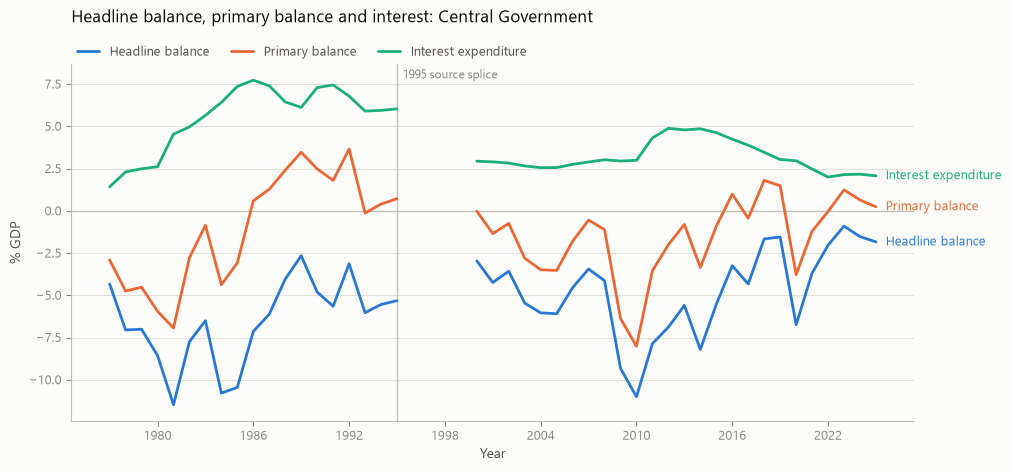

In [3]:
figure = figures.primary_vs_headline(primary, 'central_government')

## 2. The headline sign is not the primary sign

Central Government records a negative B.9 in every year of the canonical panel.
Read alone, that invites the conclusion that the subsector runs an underlying
deficit throughout. The detailed accounts do not support it.

Both statements below are descriptive and they are not in conflict: the headline
balance is negative throughout, while the primary balance, which excludes interest
by construction, is positive in a non-trivial minority of the observed years.
Interest is the arithmetic that separates them.

In [4]:
signs = pd.read_csv(TABLES / 'primary_balance_sign_summary.csv')
display(signs.round(3))

,sector,first_year,last_year,n_years,headline_positive_years,headline_negative_years,primary_positive_years,primary_negative_years,primary_positive_year_list,mean_interest_pct_gdp,max_interest_pct_gdp
0,central_government,1977,2025,45,0,45,15,30,1986;1987;1988;1989;1990;1991;1992;1994;1995;2...,4.174,7.731
1,general_government,1977,2025,49,4,45,22,27,1986;1987;1988;1989;1990;1991;1992;1993;1994;1...,4.164,7.890
2,regional_local_government,1977,2025,45,16,29,20,25,1977;1978;1979;1986;1987;1988;1991;1992;1994;1...,0.129,0.623
3,social_security_funds,1977,2025,45,39,6,39,6,1978;1979;1980;1982;1983;1984;1985;1986;1987;1...,0.005,0.044


In [5]:
central_signs = signs.loc[signs['sector'].eq('central_government')].iloc[0]
print('observed years:', int(central_signs['n_years']))
print('headline balance negative in:', int(central_signs['headline_negative_years']))
print('primary balance positive in:', int(central_signs['primary_positive_years']))
print('those years:', central_signs['primary_positive_year_list'])

observed years: 45
headline balance negative in: 45
primary balance positive in: 15
those years: 1986;1987;1988;1989;1990;1991;1992;1994;1995;2016;2018;2019;2023;2024;2025


## 3. Interest across sectors

Interest is overwhelmingly a Central Government item, which is why the primary
and headline balances of the other subsectors nearly coincide.

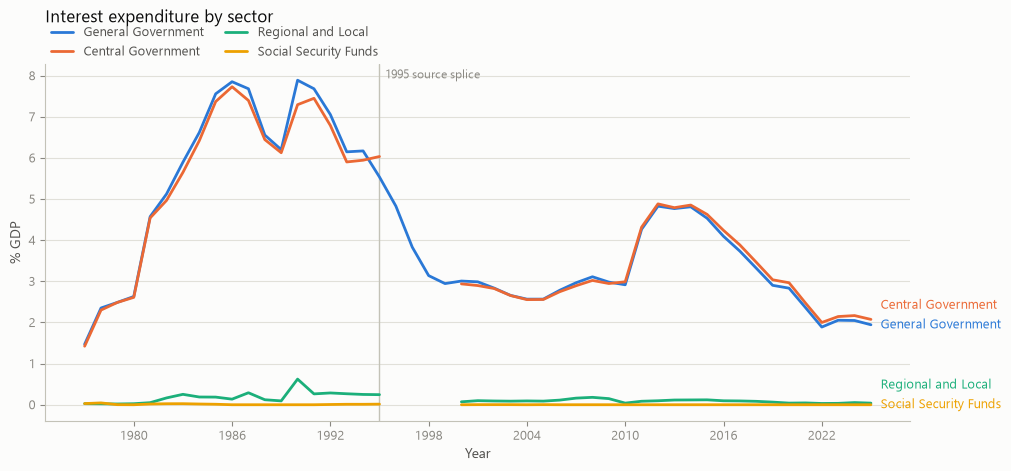

In [6]:
figure = figures.interest_burden(primary)

In [7]:
display(
    primary.groupby('sector')[['interest_pct_gdp', 'primary_balance_pct_gdp']]
    .agg(['mean', 'min', 'max'])
    .round(3)
)

interest_pct_gdp               primary_balance_pct_gdp              
                                      mean    min    max                    mean    min    max
sector                                                                                        
central_government                   4.174  1.423  7.731                  -1.310 -8.019  3.657
general_government                   4.164  1.470  7.890                  -0.751 -8.502  4.110
regional_local_government            0.129  0.018  0.623                  -0.041 -0.818  0.592
social_security_funds                0.005  0.000  0.044                   0.645 -0.451  2.303

## Interpretation limits

1. The primary balance **excludes interest by construction**. It is not a measure
   of discretionary policy and not a cyclically adjusted balance.
2. **A positive primary balance is not a sustainability result** and a negative
   headline balance is not an unsustainability result. Neither says anything about
   the debt path on its own.
3. Interest reflects the **debt stock and past financing conditions**, so a
   primary-balance comparison across decades compares different debt structures.
4. The sign counts are taken over the **detailed account panel**, so the three
   subsectors have 45 observations rather than the 49 of the canonical balance
   panel: the 1996-1999 components are missing.
5. The identity check confirms the **arithmetic**, not the appropriateness of the
   published interest series.

---

[Previous: 10. Intergovernmental transfer sensitivity](10_intergovernmental_transfers.ipynb) | [Next: 12. Fixed-capital-formation diagnostic](12_investment_diagnostic.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```